# 🧠 Minería de Datos — Support Vector Machine (SVM)
## Notebook autónomo explicado para estudiantes

Este notebook introduce el modelo **Support Vector Machine (SVM)** para clasificación supervisada.

SVM aparece dentro del bloque de clasificación del syllabus y permite entender otra forma de construir modelos:

> En vez de votar como KNN, o crear reglas como un árbol, SVM busca una frontera óptima de separación.

---

## Objetivos

Al finalizar este notebook podrás:

1. Explicar la idea general de SVM.
2. Comprender qué es un hiperplano.
3. Entender el concepto de margen.
4. Identificar qué son los support vectors.
5. Aplicar SVM con kernel lineal.
6. Aplicar SVM con kernel RBF.
7. Comprender la importancia del escalado.
8. Evaluar modelos SVM con métricas de clasificación.
9. Comparar SVM contra otros modelos.
10. Analizar el efecto de los parámetros `C` y `gamma`.

# 1. Idea central de SVM

SVM significa:

# Support Vector Machine

La idea principal es:

> encontrar la frontera que mejor separa las clases.

En clasificación binaria, esa frontera puede verse como una línea.

En más dimensiones, se llama:

# hiperplano

---

## Ejemplo intuitivo

Si tenemos dos grupos de puntos, SVM busca una línea que los separe dejando el mayor espacio posible entre las clases.

Ese espacio se llama:

# margen

---

## Frase clave

> SVM no busca cualquier separación; busca la separación con el mayor margen.

# 2. Conceptos principales

## Hiperplano

Es la frontera de decisión que separa las clases.

En 2D es una línea.  
En 3D es un plano.  
En más dimensiones es un hiperplano.

---

## Margen

Es la distancia entre el hiperplano y los puntos más cercanos de cada clase.

SVM intenta maximizar este margen.

---

## Support Vectors

Son los puntos más cercanos al hiperplano.

Estos puntos son muy importantes porque determinan la posición de la frontera.

---

## Kernel

Cuando los datos no se pueden separar linealmente, SVM puede usar kernels.

Un kernel permite construir fronteras no lineales.

Kernels comunes:

| Kernel | Uso |
|---|---|
| linear | separación lineal |
| poly | frontera polinómica |
| rbf | frontera no lineal flexible |

# 3. Importación de librerías

Usaremos:

- `pandas` y `numpy` para datos.
- `matplotlib` para gráficos.
- `load_breast_cancer` como dataset real.
- `StandardScaler` para escalar.
- `SVC` para SVM.
- métricas de clasificación.
- modelos adicionales para comparación.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)

# 4. Dataset real: Breast Cancer Wisconsin

Usaremos un dataset real incluido en scikit-learn.

El problema consiste en clasificar tumores como:

- malignos
- benignos

La variable objetivo es binaria.

Este dataset es útil porque permite trabajar clasificación en un contexto realista.

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dimensiones de X:", X.shape)
print("Dimensión de y:", y.shape)
print("Clases:", data.target_names)

X.head()

Dimensiones de X: (569, 30)
Dimensión de y: (569,)
Clases: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# 5. Exploración inicial

Antes de entrenar el modelo revisamos:

1. cantidad de observaciones,
2. cantidad de variables,
3. valores faltantes,
4. distribución de la variable objetivo.

In [4]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
X.isna().sum().sum()

np.int64(0)

In [6]:
conteo = y.value_counts().sort_index()
porcentaje = y.value_counts(normalize=True).sort_index() * 100

resumen_clases = pd.DataFrame({
    "codigo": conteo.index,
    "clase": data.target_names,
    "conteo": conteo.values,
    "porcentaje": porcentaje.round(2).values
})

resumen_clases

,codigo,clase,conteo,porcentaje
0,0,malignant,212,37.26
1,1,benign,357,62.74


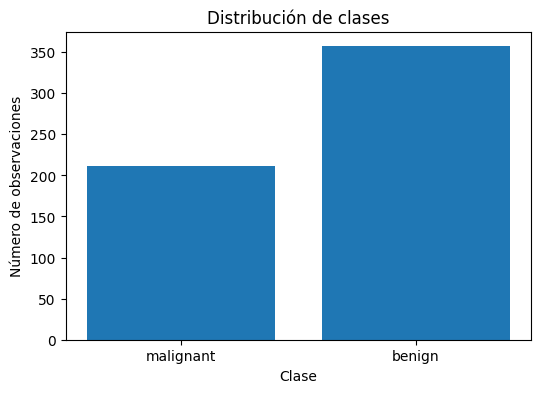

In [7]:
plt.figure(figsize=(6,4))
plt.bar(resumen_clases["clase"], resumen_clases["conteo"])
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Número de observaciones")
plt.show()

# 6. Separación train/test

Separamos los datos en:

- entrenamiento: 70%
- prueba: 30%

Usamos `stratify=y` para mantener proporciones similares de clases.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\nDistribución train:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nDistribución test:")
print(y_test.value_counts(normalize=True).sort_index())

Train: (398, 30)
Test: (171, 30)

Distribución train:
target
0    0.371859
1    0.628141
Name: proportion, dtype: float64

Distribución test:
target
0    0.374269
1    0.625731
Name: proportion, dtype: float64


# 7. ¿Por qué SVM necesita escalado?

SVM depende de distancias y márgenes.

Si una variable tiene valores muy grandes, puede dominar el modelo.

Por eso se usa:

# StandardScaler

Esto transforma las variables para que tengan:

- media aproximada 0,
- desviación estándar aproximada 1.

Usaremos `Pipeline` para evitar fuga de información.

# 8. Función de evaluación

Usaremos las mismas métricas que en clasificación:

- accuracy
- precision
- recall
- F1-score

In [9]:
def evaluar_clasificacion(nombre, y_real, y_pred):
    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred),
        "recall": recall_score(y_real, y_pred),
        "f1": f1_score(y_real, y_pred)
    }

# 9. SVM con kernel lineal

El kernel lineal busca una frontera lineal.

Es útil cuando las clases pueden separarse razonablemente con una frontera simple.

Parámetro importante:

- `C`: controla la regularización.

Un C alto intenta clasificar mejor el entrenamiento, pero puede sobreajustar.

Un C bajo permite más errores, pero puede generalizar mejor.

In [10]:
svm_lineal = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", C=1.0, random_state=42))
])

svm_lineal.fit(X_train, y_train)

pred_svm_lineal = svm_lineal.predict(X_test)

print(classification_report(y_test, pred_svm_lineal, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.97      0.98        64
      benign       0.98      0.99      0.99       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



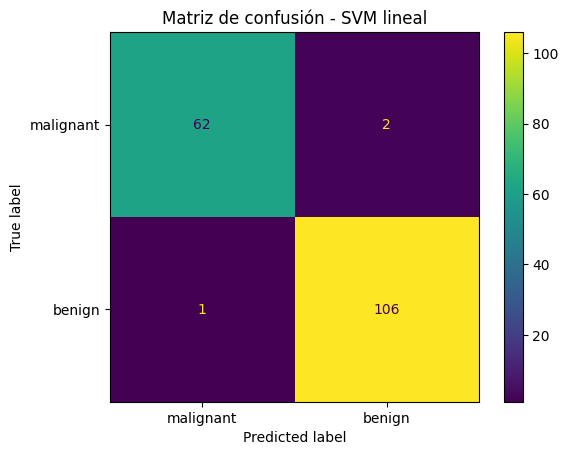

In [11]:
cm = confusion_matrix(y_test, pred_svm_lineal)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title("Matriz de confusión - SVM lineal")
plt.show()

# 10. SVM con kernel RBF

El kernel RBF permite fronteras no lineales.

Es uno de los kernels más usados.

Parámetros importantes:

## C

Controla regularización.

## gamma

Controla qué tan fuerte influye cada punto.

- gamma bajo: frontera más suave.
- gamma alto: frontera más compleja.

---

## Riesgo

Un gamma muy alto puede generar sobreajuste.

In [12]:
svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

svm_rbf.fit(X_train, y_train)

pred_svm_rbf = svm_rbf.predict(X_test)

print(classification_report(y_test, pred_svm_rbf, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.97      0.97      0.97        64
      benign       0.98      0.98      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



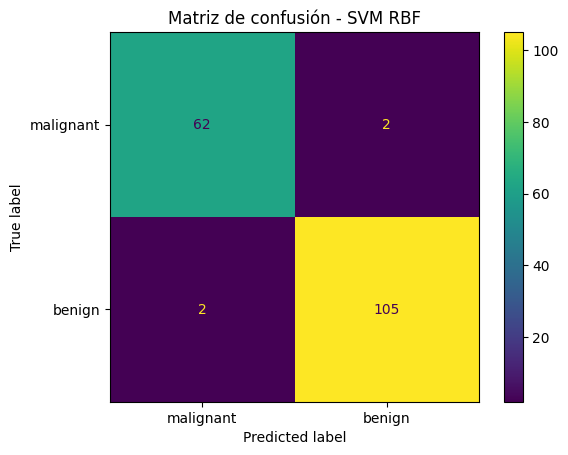

In [13]:
cm = confusion_matrix(y_test, pred_svm_rbf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title("Matriz de confusión - SVM RBF")
plt.show()

# 11. Comparación SVM lineal vs SVM RBF

Comparamos ambos modelos SVM usando las mismas métricas.

In [14]:
comparacion_svm = pd.DataFrame([
    evaluar_clasificacion("SVM lineal", y_test, pred_svm_lineal),
    evaluar_clasificacion("SVM RBF", y_test, pred_svm_rbf)
])

comparacion_svm

,modelo,accuracy,precision,recall,f1
0,SVM lineal,0.982456,0.981481,0.990654,0.986047
1,SVM RBF,0.976608,0.981308,0.981308,0.981308


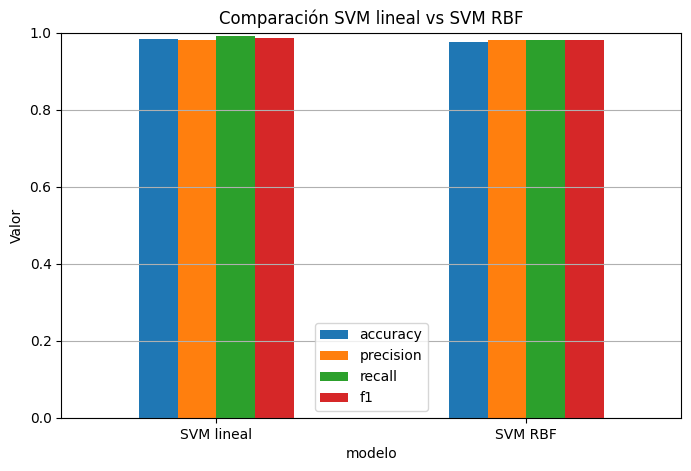

In [15]:
metricas = ["accuracy", "precision", "recall", "f1"]

comparacion_svm.set_index("modelo")[metricas].plot(kind="bar", figsize=(8,5))
plt.title("Comparación SVM lineal vs SVM RBF")
plt.ylabel("Valor")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

# 12. Comparación contra otros modelos

Ahora comparamos SVM con modelos vistos en el curso:

1. Regresión logística.
2. KNN.
3. Árbol.
4. Random Forest.
5. SVM lineal.
6. SVM RBF.

Esto ayuda a ubicar SVM dentro del conjunto de modelos supervisados.

In [16]:
modelo_logistica = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

modelo_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

modelo_arbol = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

modelos = {
    "Regresión logística": modelo_logistica,
    "KNN": modelo_knn,
    "Árbol": modelo_arbol,
    "Random Forest": modelo_rf,
    "SVM lineal": svm_lineal,
    "SVM RBF": svm_rbf
}

resultados = []

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    resultados.append(evaluar_clasificacion(nombre, y_test, pred))

df_resultados = pd.DataFrame(resultados).sort_values("f1", ascending=False)

df_resultados

,modelo,accuracy,precision,recall,f1
0,Regresión logística,0.988304,0.990654,0.990654,0.990654
4,SVM lineal,0.982456,0.981481,0.990654,0.986047
5,SVM RBF,0.976608,0.981308,0.981308,0.981308
1,KNN,0.959064,0.938596,1.000000,0.968326
3,Random Forest,0.941520,0.944954,0.962617,0.953704
2,Árbol,0.923977,0.935185,0.943925,0.939535


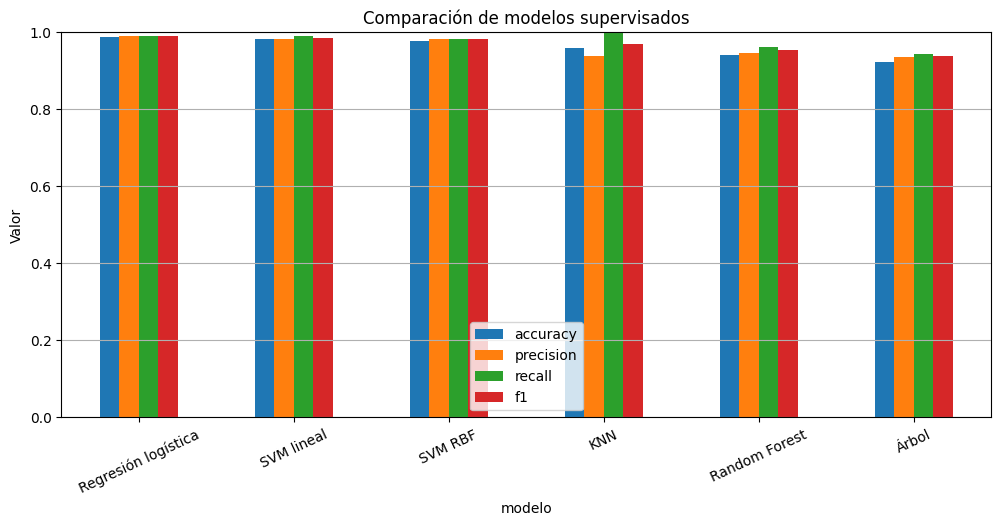

In [17]:
df_resultados.set_index("modelo")[metricas].plot(kind="bar", figsize=(12,5))
plt.title("Comparación de modelos supervisados")
plt.ylabel("Valor")
plt.ylim(0,1)
plt.xticks(rotation=25)
plt.grid(axis="y")
plt.show()

# 13. Efecto del parámetro C

El parámetro `C` controla la regularización.

- C pequeño: más regularización, margen más amplio, permite más errores.
- C grande: menos regularización, intenta clasificar mejor entrenamiento.

Probemos varios valores.

In [18]:
valores_C = [0.01, 0.1, 1, 10, 100]
resultados_C = []

for C in valores_C:
    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=C, gamma="scale", random_state=42))
    ])

    modelo.fit(X_train, y_train)
    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    resultados_C.append({
        "C": C,
        "accuracy_train": accuracy_score(y_train, pred_train),
        "accuracy_test": accuracy_score(y_test, pred_test),
        "f1_test": f1_score(y_test, pred_test)
    })

df_C = pd.DataFrame(resultados_C)

df_C

,C,accuracy_train,accuracy_test,f1_test
0,0.01,0.628141,0.625731,0.769784
1,0.10,0.959799,0.935673,0.950226
2,1.00,0.982412,0.976608,0.981308
3,10.00,0.992462,0.976608,0.981308
4,100.00,1.000000,0.923977,0.939535


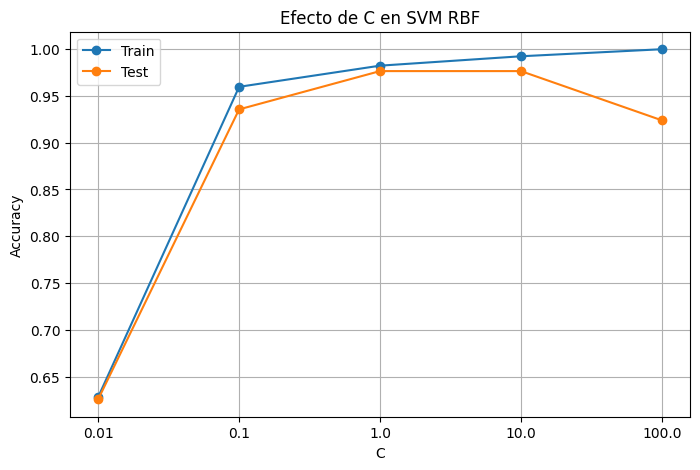

In [19]:
plt.figure(figsize=(8,5))
plt.plot(df_C["C"].astype(str), df_C["accuracy_train"], marker="o", label="Train")
plt.plot(df_C["C"].astype(str), df_C["accuracy_test"], marker="o", label="Test")
plt.title("Efecto de C en SVM RBF")
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 14. Efecto del parámetro gamma

Gamma controla la influencia de cada punto.

- gamma bajo: frontera suave.
- gamma alto: frontera más flexible.

Un gamma demasiado alto puede sobreajustar.

In [20]:
valores_gamma = [0.001, 0.01, 0.1, 1, 10]
resultados_gamma = []

for gamma in valores_gamma:
    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1.0, gamma=gamma, random_state=42))
    ])

    modelo.fit(X_train, y_train)
    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    resultados_gamma.append({
        "gamma": gamma,
        "accuracy_train": accuracy_score(y_train, pred_train),
        "accuracy_test": accuracy_score(y_test, pred_test),
        "f1_test": f1_score(y_test, pred_test)
    })

df_gamma = pd.DataFrame(resultados_gamma)

df_gamma

,gamma,accuracy_train,accuracy_test,f1_test
0,0.001,0.949749,0.941520,0.955357
1,0.010,0.979899,0.964912,0.972477
2,0.100,0.984925,0.959064,0.966825
3,1.000,1.000000,0.625731,0.769784
4,10.000,1.000000,0.625731,0.769784


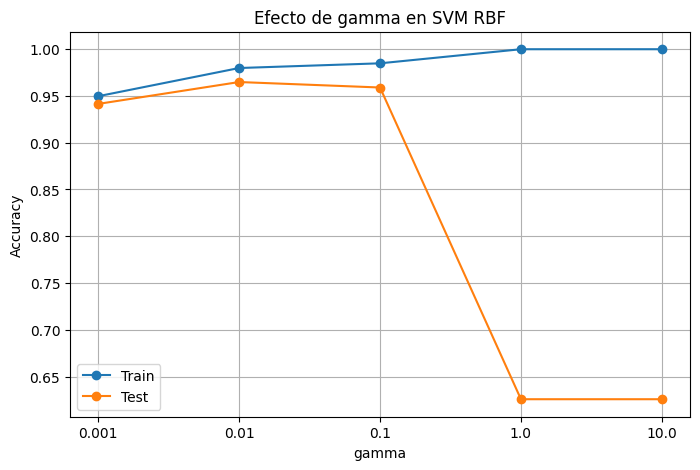

In [21]:
plt.figure(figsize=(8,5))
plt.plot(df_gamma["gamma"].astype(str), df_gamma["accuracy_train"], marker="o", label="Train")
plt.plot(df_gamma["gamma"].astype(str), df_gamma["accuracy_test"], marker="o", label="Test")
plt.title("Efecto de gamma en SVM RBF")
plt.xlabel("gamma")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 15. Visualización didáctica en 2D

Para visualizar una frontera de decisión, usaremos solo dos variables.

Esto es solo con fines pedagógicos.

Variables usadas:

- mean radius
- mean texture

In [22]:
X_2d = X[["mean radius", "mean texture"]]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

modelo_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

modelo_2d.fit(X2_train, y2_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', SVC())])

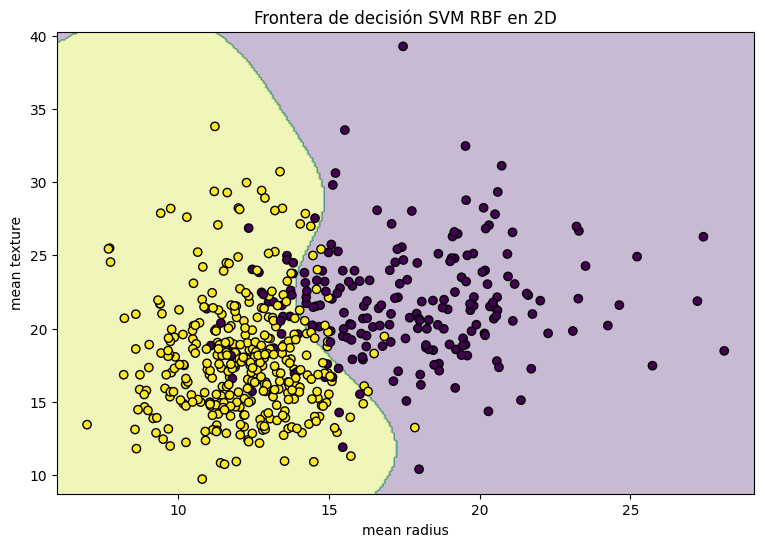

In [23]:
x_min, x_max = X_2d.iloc[:,0].min() - 1, X_2d.iloc[:,0].max() + 1
y_min, y_max = X_2d.iloc[:,1].min() - 1, X_2d.iloc[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = pd.DataFrame({
    "mean radius": xx.ravel(),
    "mean texture": yy.ravel()
})

Z = modelo_2d.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_2d.iloc[:,0], X_2d.iloc[:,1], c=y, edgecolor="k")
plt.xlabel("mean radius")
plt.ylabel("mean texture")
plt.title("Frontera de decisión SVM RBF en 2D")
plt.show()

# 16. Ventajas y desventajas de SVM

## Ventajas

- Puede funcionar muy bien en clasificación.
- Maximiza margen.
- Soporta kernels no lineales.
- Es potente en espacios de muchas dimensiones.

## Desventajas

- Requiere escalado.
- Puede ser menos interpretable.
- Puede ser costoso en datasets grandes.
- Requiere ajustar C y gamma.
- No entrega explicaciones tan simples como un árbol.

# 17. Cuándo usar SVM

## Usar SVM cuando:

- hay clasificación con muchas variables,
- se necesita una frontera potente,
- los datos no son demasiado grandes,
- se puede escalar correctamente,
- se acepta menor interpretabilidad.

## Evitar o usar con cuidado cuando:

- el dataset es enorme,
- se necesita explicación simple,
- no se pueden ajustar hiperparámetros,
- hay muchas variables categóricas sin preparar.

# 18. Taller autónomo

## Parte A — Conceptos

Responda:

1. ¿Qué significa SVM?
2. ¿Qué es un hiperplano?
3. ¿Qué es el margen?
4. ¿Qué son los support vectors?
5. ¿Para qué sirve un kernel?
6. ¿Por qué SVM necesita escalado?

---

## Parte B — Implementación

1. Entrene SVM lineal.
2. Entrene SVM RBF.
3. Compare accuracy, precision, recall y F1.
4. Genere matriz de confusión para ambos.

---

## Parte C — Parámetros

1. Pruebe C = 0.01, 0.1, 1, 10 y 100.
2. Pruebe gamma = 0.001, 0.01, 0.1, 1 y 10.
3. Explique qué configuración funcionó mejor.
4. Identifique si hay señales de sobreajuste.

---

## Parte D — Comparación

Compare SVM contra:

1. Regresión logística.
2. KNN.
3. Árbol.
4. Random Forest.

Responda:

1. ¿Cuál tuvo mejor F1?
2. ¿Cuál fue más interpretable?
3. ¿Cuál depende más del escalado?
4. ¿Cuál recomendaría y por qué?

---

## Parte E — Conclusión

Redacte mínimo 10 líneas indicando:

1. Qué aprendió de SVM.
2. Qué kernel funcionó mejor.
3. Qué efecto tuvo C.
4. Qué efecto tuvo gamma.
5. Qué modelo recomendaría para el dataset.

# 19. Rúbrica sugerida

| Criterio | Puntaje |
|---|---:|
| Comprensión conceptual de SVM | 0.8 |
| Implementación de SVM lineal y RBF | 0.8 |
| Evaluación con métricas y matriz de confusión | 0.8 |
| Análisis de C y gamma | 1.0 |
| Comparación contra otros modelos | 0.9 |
| Conclusión técnica | 0.7 |
| **Total** | **5.0** |

---

# Cierre

SVM completa el bloque de clasificación del curso.

Su idea central es:

> encontrar una frontera de decisión que maximice el margen entre clases.

A diferencia de árboles o Random Forest, SVM no se interpreta como reglas simples.

A diferencia de KNN, SVM aprende una frontera.

A diferencia de regresión logística, puede usar kernels para separar datos no lineales.